# 03 · Data Understanding (2/2) — Deskripsi, Kualitas & Eksplorasi Data
Fase CRISP-DM 2, tugas **Describe Data → Verify Data Quality → Explore Data**.

Pertanyaan yang dijawab:
1. Seperti apa struktur & kelengkapan data tiap jenis pasar?
2. Masalah kualitas apa yang harus dibereskan di fase *Data Preparation*?
3. Seberapa sering "lonjakan" terjadi per komoditas → **apakah ambang 15% masuk akal untuk semua komoditas?**
4. Apakah ada pola musiman (Ramadan–Idulfitri, Nataru), pola spasial, sinyal dari harga produsen, dan keterkaitan antarprovinsi yang bisa dijadikan fitur?

In [1]:
# --- Setup: path project, modul radarpangan, gaya grafik -----------------------------------
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from radarpangan.config import load_project
cfg, P = load_project(ROOT)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
print("Project:", ROOT)

Project: /home/claude/MiningProcess


In [2]:
from radarpangan.pipeline import load_refs
from radarpangan.cleaning import long_to_wide, detect_bad_values, build_price_panels
from radarpangan.labeling import make_labels, events_table, threshold_per_column
from radarpangan.viz import plot_choropleth, PALETTE
from radarpangan.geo import load_geojson

refs = load_refs(P)
long = pd.read_parquet(P.interim / "pihps_long.parquet")
geo = load_geojson(P.external / "indonesia_provinces.geojson")
REP = {"cat_1": "com_3", "cat_2": "com_7", "cat_3": "com_8", "cat_4": "com_10", "cat_5": "com_11",
       "cat_6": "com_12", "cat_7": "com_14", "cat_8": "com_16", "cat_9": "com_17", "cat_10": "com_21"}
print(f"{len(long):,} baris, {long.memory_usage(deep=True).sum()/1e6:.0f} MB")

5,450,980 baris, 806 MB


## 3.1 Deskripsi data

In [3]:
display(long.dtypes.rename("tipe").to_frame().T)
desc = long.groupby(["price_type", "category"], observed=True)["price"].describe()[["count", "mean", "min", "50%", "max"]]
display(desc.round(0))

,date,price_type_id,price_type,commodity_id,commodity,cat_id,category,province_id,province,price
tipe,datetime64[us],int64,str,str,str,str,str,int64,str,float64


count         mean         min          50%             max
price_type        category                                                                        
Pasar Modern      Bawang Merah   69,590.0000  52,395.0000 18,000.0000  50,700.0000    122,850.0000
                  Bawang Putih   69,624.0000  44,774.0000 17,450.0000  43,400.0000     94,500.0000
                  Beras         370,283.0000  14,446.0000  8,250.0000  13,950.0000    139,000.0000
                  Cabai Merah   125,025.0000  75,399.0000 12,500.0000  72,650.0000    177,900.0000
                  Cabai Rawit   121,037.0000  80,972.0000 12,500.0000  76,400.0000    250,000.0000
                  Daging Ayam    67,335.0000  42,103.0000  3,500.0000  41,750.0000    123,900.0000
                  Daging Sapi   114,198.0000 161,818.0000 13,000.0000 159,275.0000    312,000.0000
                  Gula Pasir    135,208.0000  15,744.0000  9,850.0000  14,850.0000  1,200,000.0000
                  Minyak Goreng 144,822.0000  19,919.0000  8,000.0000  20,350.0000     55,600.0000
                  Telur Ayam     69,514.0000  30,977.0000 17,000.0000  29,800.0000    116,500.0000
Pasar Tradisional Bawang Merah   77,039.0000  37,392.0000 11,550.0000  35,900.0000    100,000.0000
                  Bawang Putih   77,039.0000  35,251.0000 14,500.0000  34,950.0000    235,000.0000
                  Beras         449,387.0000  13,224.0000  7,000.0000  13,100.0000     42,250.0000
                  Cabai Merah   140,716.0000  46,015.0000  9,150.0000  43,750.0000    152,900.0000
                  Cabai Rawit   144,437.0000  51,334.0000  9,500.0000  47,150.0000    183,750.0000
                  Daging Ayam    77,037.0000  36,035.0000 17,600.0000  35,850.0000     93,950.0000
                  Daging Sapi   149,570.0000 127,592.0000 65,500.0000 126,250.0000    295,000.0000
                  Gula Pasir    151,723.0000  16,107.0000  8,850.0000  15,800.0000     62,250.0000
                  Minyak Goreng 225,886.0000  17,458.0000  5,800.0000  16,850.0000     71,500.0000
                  Telur Ayam     77,039.0000  27,830.0000 17,350.0000  27,600.0000     81,250.0000
Pedagang Besar    Bawang Merah   79,113.0000  29,282.0000  6,000.0000  28,450.0000     80,000.0000
                  Bawang Putih   79,155.0000  27,832.0000  9,500.0000  27,250.0000     76,450.0000
                  Beras         449,630.0000  12,287.0000  6,150.0000  12,050.0000     26,000.0000
                  Cabai Merah   145,782.0000  35,733.0000  4,000.0000  33,750.0000    126,350.0000
                  Cabai Rawit   145,053.0000  41,665.0000  3,500.0000  37,500.0000    176,250.0000
                  Daging Ayam    76,823.0000  29,398.0000 10,000.0000  29,000.0000     55,000.0000
                  Daging Sapi   143,798.0000 120,815.0000 55,250.0000 120,000.0000    435,000.0000
                  Gula Pasir    145,369.0000  14,481.0000  8,500.0000  14,000.0000     23,150.0000
                  Minyak Goreng 222,903.0000  15,789.0000  6,600.0000  15,300.0000     70,000.0000
                  Telur Ayam     79,165.0000  25,069.0000 11,500.0000  25,100.0000     91,400.0000
Produsen          Bawang Merah   51,716.0000  25,482.0000  4,500.0000  24,750.0000     70,000.0000
                  Bawang Putih    5,657.0000  19,219.0000  5,650.0000  17,500.0000     40,000.0000
                  Beras         268,768.0000  10,885.0000  2,700.0000  10,500.0000    115,000.0000
                  Cabai Merah   115,626.0000  29,409.0000  3,000.0000  27,000.0000    100,000.0000
                  Cabai Rawit   111,187.0000  34,779.0000  2,350.0000  30,650.0000    163,350.0000
                  Daging Ayam    68,491.0000  25,826.0000 10,000.0000  24,950.0000     98,000.0000
                  Daging Sapi   114,782.0000 118,405.0000 11,000.0000 117,550.0000 12,000,000.0000
                  Gula Pasir     34,362.0000  13,360.0000  7,000.0000  13,000.0000     21,150.0000
                  Minyak Goreng  61,680.0000  14,845.0000  6,400.0000  14,900.0

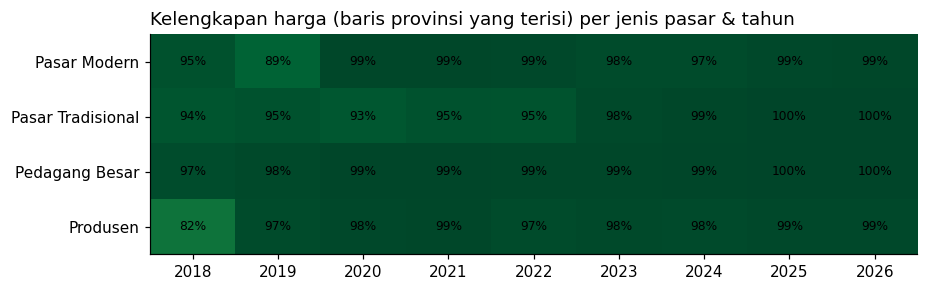

In [4]:
# Kelengkapan (% harga terisi) per jenis pasar per tahun — hanya provinsi (bukan nasional)
lp = long[long["province_id"] > 0]
cov = lp.assign(tahun=lp["date"].dt.year).groupby(["price_type", "tahun"])["price"].apply(lambda s: s.notna().mean()).unstack()
fig, ax = plt.subplots(figsize=(9, 2.6))
im = ax.imshow(cov.to_numpy(), cmap="YlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(cov.shape[1]), cov.columns); ax.set_yticks(range(cov.shape[0]), cov.index); ax.grid(False)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.iat[i, j]
        if np.isfinite(v): ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8)
ax.set_title("Kelengkapan harga (baris provinsi yang terisi) per jenis pasar & tahun", loc="left")
fig.savefig(P.figures / "fig_03_01_kelengkapan.png", dpi=160, bbox_inches="tight"); plt.show()

## 3.2 Verifikasi kualitas data

In [5]:
# (a) Baris wilayah yang tidak dikenal di data mentah (mis. baris dummy)
import gzip
known = set(refs["provinces"]["name"].str.strip()) | {"Semua Provinsi"}
odd = {}
for f in P.raw_pihps.glob("pt*/*/*.json.gz"):
    with gzip.open(f, "rt", encoding="utf-8") as fh:
        for r in json.load(fh)["data"]:
            n = str(r.get("name", "")).strip()
            if n not in known:
                vals = [v for k, v in r.items() if k not in ("no", "name", "level")]
                odd.setdefault(n, []).append((f.parts[-3], f.parts[-2], f.stem.split(".")[0], sum(v not in ("-", "", None) for v in vals)))
for n, occ in odd.items():
    print(f"Wilayah tak dikenal '{n}': muncul di {len(occ)} chunk, jumlah harga terisi = {sum(o[3] for o in occ)} -> dibuang")
    print("   contoh:", occ[:3])

Wilayah tak dikenal 'Dum': muncul di 6 chunk, jumlah harga terisi = 6 -> dibuang
   contoh: [('pt1', 'com_11', '2021-12', 1), ('pt1', 'com_16', '2021-12', 1), ('pt1', 'com_13', '2021-12', 1)]


In [6]:
# (b) Persentase harga kosong per varian x jenis pasar (hanya provinsi yang pernah punya data)
miss = (lp.groupby(["commodity", "price_type"], observed=True)["price"].apply(lambda s: s.isna().mean()).unstack())
miss = miss.loc[[refs["com_name"][c] for c in sorted(refs["com_name"], key=lambda x: int(x.split("_")[1]))]]
display(miss.style.format("{:.1%}").background_gradient(cmap="Reds", vmin=0, vmax=0.6))

price_type,Pasar Modern,Pasar Tradisional,Pedagang Besar,Produsen
commodity,,,,
Beras Kualitas Bawah I,2.6%,3.6%,0.9%,2.6%
Beras Kualitas Bawah II,2.3%,3.6%,1.1%,2.8%
Beras Kualitas Medium I,2.2%,3.5%,0.8%,2.1%
Beras Kualitas Medium II,2.4%,3.6%,0.8%,2.6%
Beras Kualitas Super I,1.9%,3.5%,0.9%,2.6%
Beras Kualitas Super II,2.3%,3.6%,0.9%,2.8%
Daging Ayam Ras Segar,2.0%,3.5%,0.9%,2.2%
Daging Sapi Kualitas 1,2.6%,3.6%,1.0%,2.3%
Daging Sapi Kualitas 2,2.8%,3.6%,1.1%,2.3%


,jenis pasar,observasi,dibuang,persen
0,Pasar Tradisional,1569873,143,0.0001
1,Pasar Modern,1286636,49,0.0000
2,Pedagang Besar,1566791,14,0.0000
3,Produsen,901570,15,0.0000


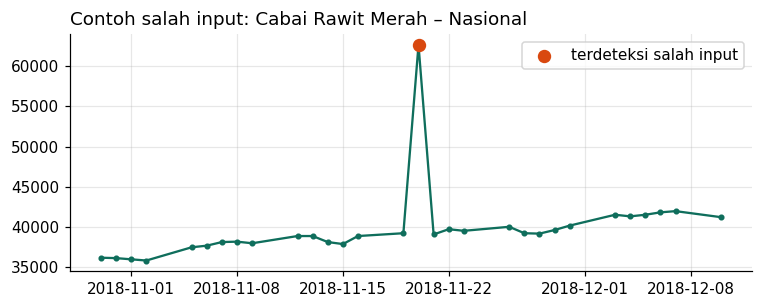

In [7]:
# (c) Nilai salah input: blip 1 hari (>50% lalu kembali) & salah skala (>4x median sekitar)
bad_summary = []
examples = {}
for pt, name in [(1, "Pasar Tradisional"), (2, "Pasar Modern"), (3, "Pedagang Besar"), (4, "Produsen")]:
    if pt not in set(long["price_type_id"]):
        continue
    w = long_to_wide(long, pt)
    bad = detect_bad_values(w, cfg["target"]["blip_log_threshold"])
    bad_summary.append({"jenis pasar": name, "observasi": int(w.notna().sum().sum()), "dibuang": int(bad.sum().sum())})
    if bad.to_numpy().any() and not examples:
        col = bad.sum().idxmax(); t = bad.index[bad[col]].tolist()[0]
        examples = {"pt": pt, "col": col, "t": t, "w": w}
bs = pd.DataFrame(bad_summary); bs["persen"] = bs["dibuang"] / bs["observasi"]
display(bs)
if examples:
    w, col, t = examples["w"], examples["col"], examples["t"]
    seg = w[col].dropna(); i = seg.index.get_loc(t); seg = seg.iloc[max(0, i - 15): i + 15]
    fig, ax = plt.subplots(figsize=(8, 2.8))
    ax.plot(seg.index, seg.values, marker="o", ms=3, color=PALETTE["accent"])
    ax.scatter([t], [w.at[t, col]], color=PALETTE["high"], zorder=5, s=60, label="terdeteksi salah input")
    ax.set_title(f"Contoh salah input: {refs['com_name'][col[0]]} – {refs['prov_name'].get(col[1], 'Nasional')}", loc="left")
    ax.legend(); fig.savefig(P.figures / "fig_03_02_contoh_blip.png", dpi=160, bbox_inches="tight"); plt.show()

In [8]:
# (d) Harga "macet" (tidak berubah lama) — indikasi survei tidak diperbarui
w1 = long_to_wide(long, 1)
def longest_flat_run(s):
    v = s.dropna().to_numpy()
    if len(v) < 2: return 0
    same = np.r_[False, v[1:] == v[:-1]]
    best = cur = 0
    for x in same:
        cur = cur + 1 if x else 0; best = max(best, cur)
    return best
runs = w1.apply(longest_flat_run)
cat_of = {c: refs["cat_name"][refs["c2cat"][c]] for c in refs["c2cat"]}
rr = runs.rename("run").reset_index(); rr["kategori"] = rr["commodity_id"].map(cat_of)
display(rr.groupby("kategori")["run"].describe()[["50%", "75%", "max"]].rename(columns={"50%": "median"}).round(0))
print(f"Seri dengan harga tak berubah > 120 hari kerja berturut-turut: {int((runs > 120).sum())} dari {len(runs)}")
print("-> Harga beras, daging sapi, gula, dan minyak goreng di banyak provinsi 'lengket' (jarang berubah berbulan-bulan).")
print("   Bukan error, tapi artinya perubahan kecil pun sudah bermakna -> mendukung ambang lonjakan yang lebih rendah.")

,median,75%,max
kategori,,,
Bawang Merah,10.0000,20.0000,52.0000
Bawang Putih,25.0000,40.0000,115.0000
Beras,129.0000,222.0000,897.0000
Cabai Merah,7.0000,10.0000,315.0000
Cabai Rawit,7.0000,13.0000,135.0000
Daging Ayam,12.0000,18.0000,104.0000
Daging Sapi,176.0000,228.0000,603.0000
Gula Pasir,116.0000,179.0000,369.0000
Minyak Goreng,100.0000,157.0000,313.0000


Seri dengan harga tak berubah > 120 hari kerja berturut-turut: 241 dari 724
-> Harga beras, daging sapi, gula, dan minyak goreng di banyak provinsi 'lengket' (jarang berubah berbulan-bulan).
   Bukan error, tapi artinya perubahan kecil pun sudah bermakna -> mendukung ambang lonjakan yang lebih rendah.


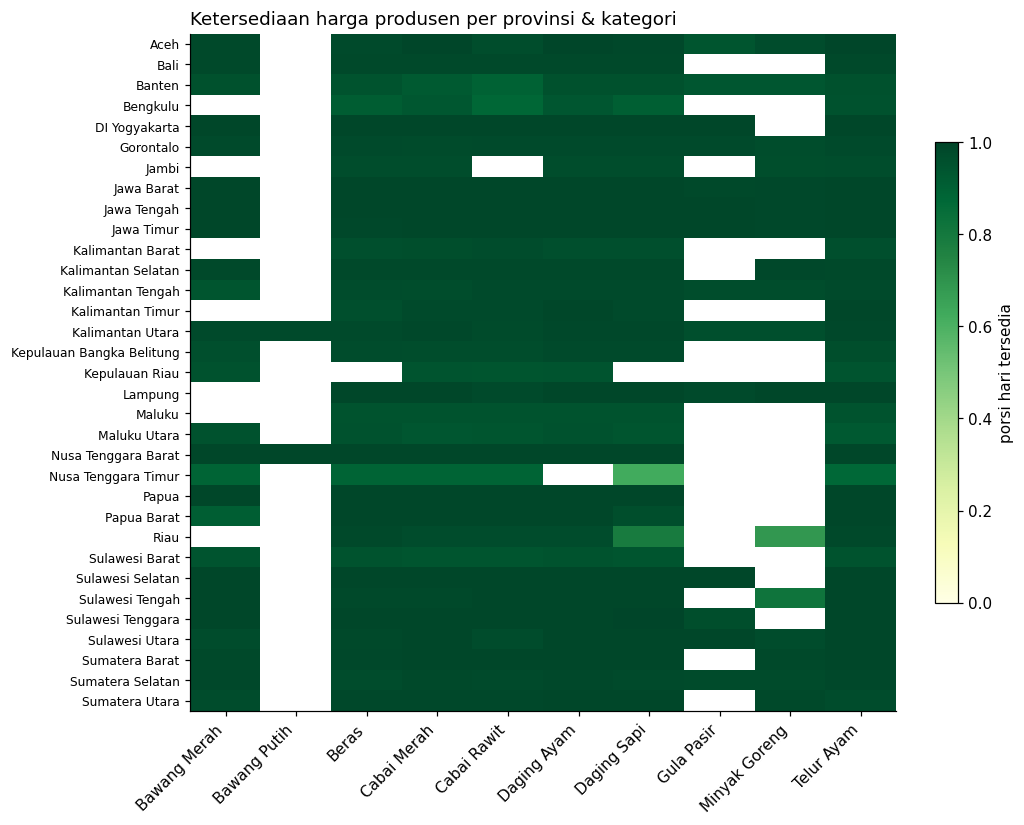

Rata-rata ketersediaan harga produsen: 97%


In [9]:
# (e) Ketersediaan harga PRODUSEN per provinsi x kategori (penting untuk fitur margin)
if 4 in set(long["price_type_id"]):
    lpro = long[(long["price_type_id"] == 4) & (long["province_id"] > 0)]
    av = lpro.groupby(["province", "category"], observed=True)["price"].apply(lambda s: s.notna().mean()).unstack()
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(av.to_numpy(), cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_yticks(range(len(av)), av.index, fontsize=8); ax.set_xticks(range(av.shape[1]), av.columns, rotation=45, ha="right")
    ax.grid(False); plt.colorbar(im, fraction=0.03, label="porsi hari tersedia")
    ax.set_title("Ketersediaan harga produsen per provinsi & kategori", loc="left")
    fig.savefig(P.figures / "fig_03_03_ketersediaan_produsen.png", dpi=160, bbox_inches="tight"); plt.show()
    print(f"Rata-rata ketersediaan harga produsen: {av.to_numpy()[np.isfinite(av.to_numpy())].mean():.0%}")

**Kesimpulan kualitas data** → tindakan di *Data Preparation*:
1. Baris wilayah dummy (kosong) → dibuang saat parsing.
2. Salah input (blip/salah skala) jumlahnya kecil tapi bisa memicu "lonjakan palsu" → dibuang sebelum smoothing.
3. Data hanya hari kerja + ada bolong → panel kalender harian dengan *forward-fill* maks. 7 hari (tidak pernah mengisi dari masa depan).
4. Fluktuasi harian bising → median bergulir 3 observasi (hanya ke belakang).
5. Harga produsen/pedagang besar tidak lengkap → fitur margin dibiarkan kosong (NaN) bila tidak ada, LightGBM menangani secara native.

## 3.3 Eksplorasi
### (a) Tren harga nasional 2018–kini

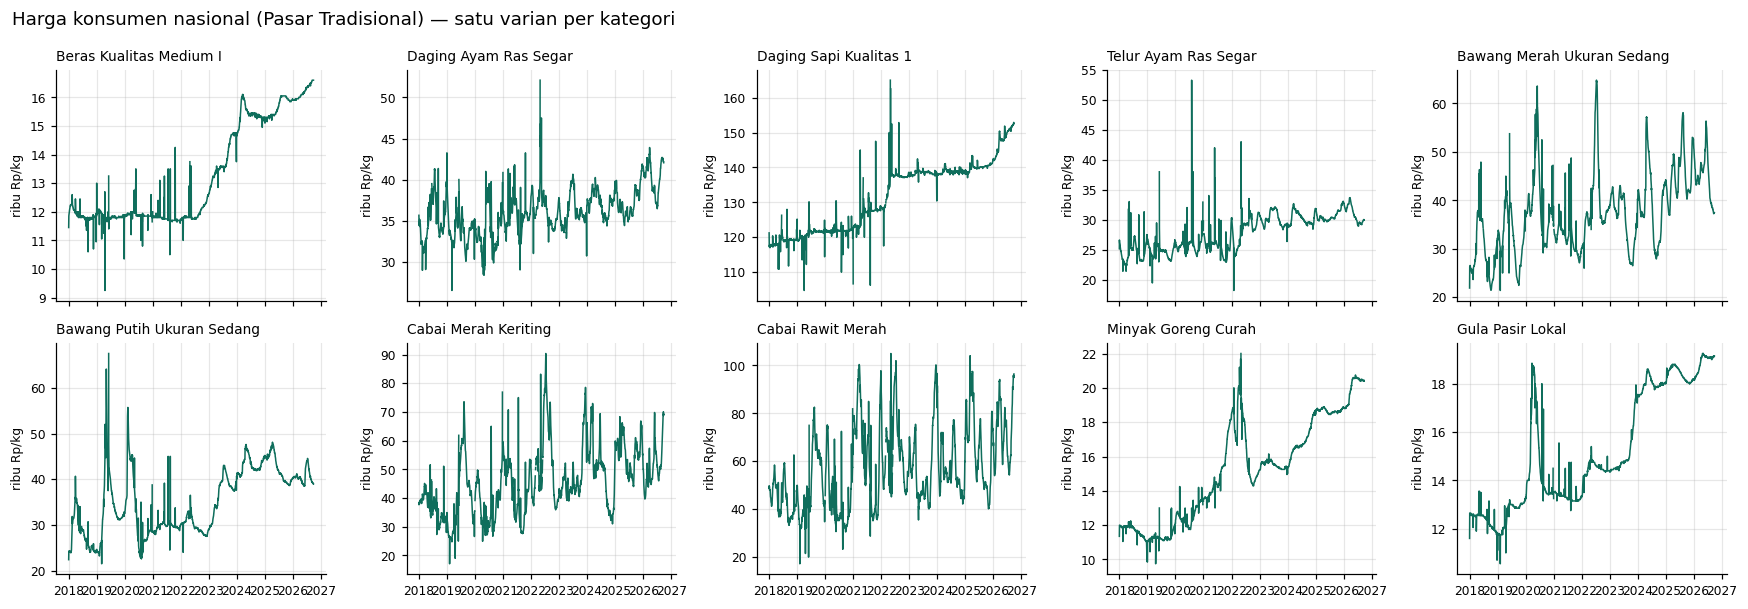

In [10]:
nat = long[(long["province_id"] == 0) & (long["price_type_id"] == 1)]
fig, axes = plt.subplots(2, 5, figsize=(16, 5.6), sharex=True)
for ax, (cat, com_id) in zip(axes.ravel(), REP.items()):
    s = nat[nat["commodity_id"] == com_id].set_index("date")["price"]
    ax.plot(s.index, s.values / 1000, lw=1, color=PALETTE["accent"])
    ax.set_title(refs["com_name"][com_id], fontsize=9, loc="left")
    ax.tick_params(labelsize=8); ax.set_ylabel("ribu Rp/kg", fontsize=8)
fig.suptitle("Harga konsumen nasional (Pasar Tradisional) — satu varian per kategori", x=0.01, ha="left")
fig.tight_layout(); fig.savefig(P.figures / "fig_03_04_tren_nasional.png", dpi=160, bbox_inches="tight"); plt.show()

### (b) Volatilitas & definisi lonjakan — apakah 15% cocok untuk semua komoditas?

,p50,p90,p95,p99
Beras,0.0%,1.1%,2.1%,5.0%
Daging Ayam,0.0%,8.3%,12.1%,21.0%
Daging Sapi,0.0%,1.0%,2.4%,6.9%
Telur Ayam,0.0%,5.2%,8.2%,15.1%
Bawang Merah,-0.1%,13.8%,19.8%,35.6%
Bawang Putih,0.0%,6.2%,10.7%,30.8%
Cabai Merah,0.0%,25.9%,37.4%,64.9%
Cabai Rawit,0.0%,26.6%,39.6%,71.4%
Minyak Goreng,0.0%,1.9%,3.4%,9.0%
Gula Pasir,0.0%,1.4%,2.6%,7.3%


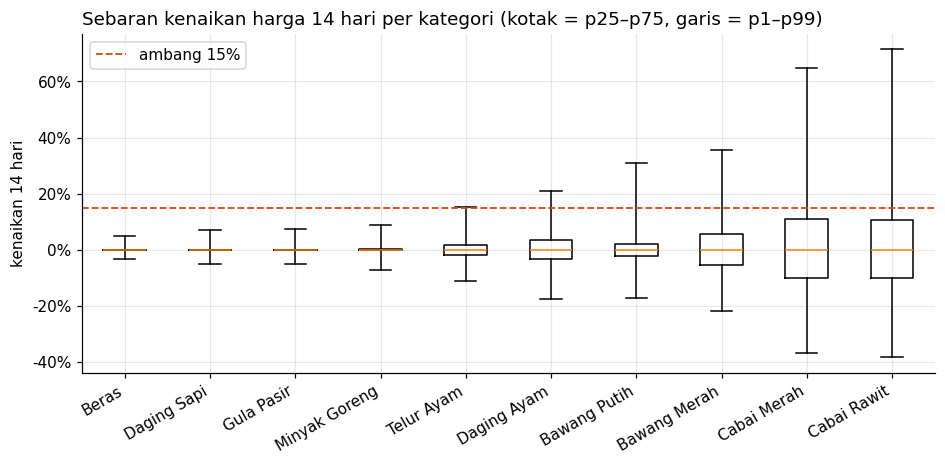

In [11]:
panels_eda, _ = build_price_panels(long[long["price_type_id"] == 1], cfg)
Pc = panels_eda[1]
prov_cols = [c for c in Pc.columns if c[1] != 0]
r14 = (Pc[prov_cols] / Pc[prov_cols].shift(14) - 1)
r14 = r14[r14.index.dayofweek < 5]
qrows, box = {}, []
for cat, cname in refs["cat_name"].items():
    cs = [c for c in prov_cols if refs["c2cat"][c[0]] == cat]
    v = r14[cs].to_numpy().ravel(); v = v[np.isfinite(v)]
    qrows[cname] = np.quantile(v, [.5, .9, .95, .99])
    box.append((cname, v))
qt = pd.DataFrame(qrows, index=["p50", "p90", "p95", "p99"]).T
display(qt.style.format("{:.1%}"))

order = qt["p99"].sort_values().index
fig, ax = plt.subplots(figsize=(10, 4))
data = [dict(box)[c] for c in order]
ax.boxplot([np.clip(d, -0.6, 1.2) for d in data], showfliers=False, whis=(1, 99))
ax.set_xticks(range(1, len(order) + 1), order, rotation=30, ha="right")
ax.axhline(0.15, color=PALETTE["high"], ls="--", lw=1.2, label="ambang 15%")
ax.set_ylabel("kenaikan 14 hari"); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Sebaran kenaikan harga 14 hari per kategori (kotak = p25–p75, garis = p1–p99)", loc="left"); ax.legend()
fig.savefig(P.figures / "fig_03_05_volatilitas.png", dpi=160, bbox_inches="tight"); plt.show()

In [12]:
# Frekuensi KEJADIAN lonjakan (onset) per seri per tahun untuk berbagai ambang
yrs = (Pc.index.max() - Pc.index.min()).days / 365.25
n_series = pd.Series([refs["c2cat"][c[0]] for c in prov_cols]).value_counts()
tab = {}
for thr in [0.03, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30]:
    ev = events_table(make_labels(Pc, thr, cfg), Pc)
    ev = ev[ev["province_id"] > 0]
    tab[f"{thr:.1%}"] = ev.groupby(ev["commodity_id"].map(refs["c2cat"])).size() / n_series / yrs
rate = pd.DataFrame(tab).fillna(0); rate.index = rate.index.map(refs["cat_name"]); rate.index.name = "kategori"
rate.columns.name = "ambang"
display(rate.style.format("{:.2f}").background_gradient(cmap="Blues", axis=None))
rate.to_csv(P.tables / "03_frekuensi_lonjakan_per_ambang.csv")

ambang,3.0%,5.0%,7.5%,10.0%,15.0%,20.0%,30.0%
kategori,,,,,,,
Beras,0.84,0.39,0.14,0.06,0.01,0.00,0.00
Gula Pasir,1.02,0.58,0.28,0.16,0.08,0.03,0.01
Daging Ayam,6.02,5.25,3.97,2.89,1.34,0.64,0.17
Daging Sapi,1.53,0.81,0.43,0.22,0.08,0.03,0.00
Telur Ayam,3.89,2.86,1.86,1.35,0.50,0.17,0.05
Bawang Merah,4.50,4.31,3.93,3.53,2.69,1.80,0.77
Bawang Putih,4.27,3.12,2.12,1.53,0.86,0.59,0.37
Cabai Merah,6.00,6.04,5.98,5.72,5.12,4.37,2.95
Cabai Rawit,5.44,5.39,5.12,4.87,4.21,3.61,2.54


**Temuan kunci (→ iterasi ke Business Understanding):** dengan ambang 15%, cabai & bawang merah "melonjak" 3–5 kali per provinsi per tahun, tetapi **beras hampir tidak pernah** (≈0,01 kali/tahun), begitu pula gula, minyak goreng, dan daging sapi. Padahal bagi komoditas yang harganya stabil/diatur, kenaikan 5–7,5% dalam dua minggu sudah luar biasa (≈ persentil ke-99).

**Keputusan:** ambang lonjakan disesuaikan volatilitas alami (disimpan di `config.yaml → target.threshold_overrides`):
Beras **5%**; Gula, Minyak Goreng, Daging Sapi **7,5%**; komoditas lain tetap **15%**. Dengan begitu, sistem peringatan dini juga berguna untuk beras — komoditas dengan bobot terbesar di pengeluaran rumah tangga.

In [13]:
thr_cols = threshold_per_column(Pc.columns, refs["c2cat"], cfg)
lab = make_labels(Pc, thr_cols, cfg)
events = events_table(lab, Pc); events = events[events["province_id"] > 0].copy()
events["kategori"] = events["commodity_id"].map(refs["c2cat"]).map(refs["cat_name"])
summ = events.groupby("kategori").agg(kejadian=("date", "size"), median_kenaikan_puncak=("peak_rise_30d", "median"),
                                      median_durasi_hari=("spike_days", "median"))
n_ser_cat = pd.Series([refs["cat_name"][refs["c2cat"][c[0]]] for c in prov_cols]).value_counts()
summ["per_seri_per_tahun"] = summ["kejadian"] / n_ser_cat.reindex(summ.index) / yrs
summ["ambang"] = [thr_cols[[c for c in prov_cols if refs["cat_name"][refs["c2cat"][c[0]]] == k][0]] for k in summ.index]
display(summ.sort_values("per_seri_per_tahun", ascending=False).style.format(
    {"median_kenaikan_puncak": "{:.1%}", "per_seri_per_tahun": "{:.2f}", "median_durasi_hari": "{:.0f}", "ambang": "{:.1%}"}))
print(f"Total kejadian lonjakan (ambang final): {len(events):,} di {events['province_id'].nunique()} provinsi")

,kejadian,median_kenaikan_puncak,median_durasi_hari,per_seri_per_tahun,ambang
kategori,,,,,
Cabai Merah,2905,38.3%,9,5.12,15.0%
Cabai Rawit,2464,43.6%,10,4.21,15.0%
Bawang Merah,798,33.0%,9,2.69,15.0%
Daging Ayam,399,22.9%,6,1.34,15.0%
Bawang Putih,254,31.6%,10,0.86,15.0%
Telur Ayam,148,20.8%,7,0.50,15.0%
Minyak Goreng,387,14.3%,10,0.44,7.5%
Daging Sapi,245,10.8%,6,0.43,7.5%
Beras,689,7.9%,7,0.39,5.0%


Total kejadian lonjakan (ambang final): 8,457 di 34 provinsi


### (c) Pola musiman: harga di sekitar Idulfitri
Indeks harga nasional relatif terhadap H-60, dirata-ratakan untuk Idulfitri 2018–2026.

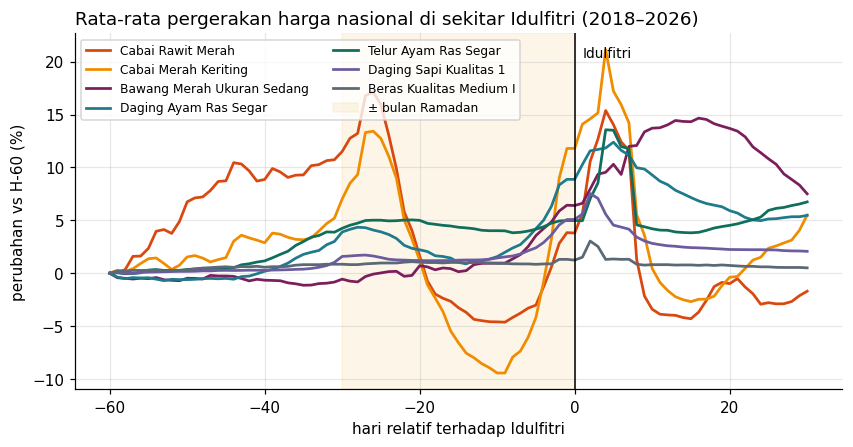

In [14]:
from radarpangan.reference import holiday_table
hol = holiday_table(2018, 2026)
lebaran = hol.loc[hol["event"] == "idulfitri", "date"]
natP = Pc.xs(0, axis=1, level=1)
fig, ax = plt.subplots(figsize=(9, 4.2))
for com_id, color in [("com_16", "#d9480f"), ("com_14", "#f08c00"), ("com_11", "#7a1f5c"), ("com_7", "#1f7a8c"),
                      ("com_10", "#0f6e5c"), ("com_8", "#6c5b9e"), ("com_3", "#5b6875")]:
    curves = []
    for d in lebaran:
        seg = natP[com_id].loc[d - pd.Timedelta(days=60): d + pd.Timedelta(days=30)]
        if len(seg) > 80 and np.isfinite(seg.iloc[0]):
            curves.append((seg / seg.iloc[0]).to_numpy()[:91])
    if curves:
        m = np.nanmean(np.vstack([c for c in curves if len(c) == 91]), axis=0)
        ax.plot(np.arange(-60, 31), (m - 1) * 100, label=refs["com_name"][com_id], color=color, lw=1.8)
ax.axvline(0, color="k", lw=1); ax.text(1, ax.get_ylim()[1] * 0.9, "Idulfitri", fontsize=9)
ax.axvspan(-30, 0, color=PALETTE["watch"], alpha=.12, label="± bulan Ramadan")
ax.set_xlabel("hari relatif terhadap Idulfitri"); ax.set_ylabel("perubahan vs H-60 (%)")
ax.set_title("Rata-rata pergerakan harga nasional di sekitar Idulfitri (2018–2026)", loc="left")
ax.legend(fontsize=8, ncol=2); fig.savefig(P.figures / "fig_03_06_pola_idulfitri.png", dpi=160, bbox_inches="tight"); plt.show()

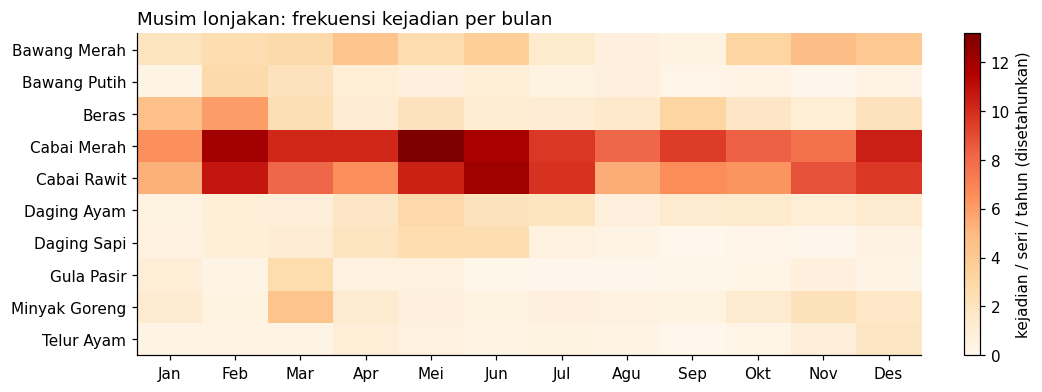

In [15]:
# Kapan lonjakan terjadi? kejadian per bulan per kategori (per seri per tahun)
events["bulan"] = events["date"].dt.month
mon = events.pivot_table(index="kategori", columns="bulan", values="date", aggfunc="size").fillna(0)
mon = mon.div(events.groupby("kategori")["province_id"].nunique(), axis=0) / yrs * 12
fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(mon.to_numpy(), cmap="OrRd", aspect="auto")
ax.set_yticks(range(len(mon)), mon.index); ax.set_xticks(range(12), ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"])
ax.grid(False); plt.colorbar(im, fraction=0.03, label="kejadian / seri / tahun (disetahunkan)")
ax.set_title("Musim lonjakan: frekuensi kejadian per bulan", loc="left")
fig.savefig(P.figures / "fig_03_07_musim_lonjakan.png", dpi=160, bbox_inches="tight"); plt.show()

### (d) Pola spasial: provinsi mana yang paling sering melonjak?

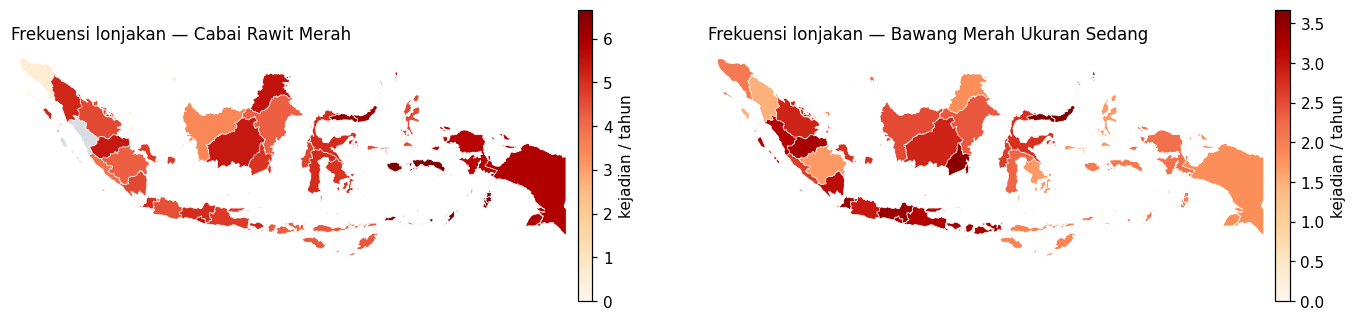

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, com_id in zip(axes, ["com_16", "com_11"]):
    e = events[events["commodity_id"] == com_id].groupby("province_id").size() / yrs
    plot_choropleth(ax, geo, e.to_dict(), cmap="OrRd", vmin=0, colorbar_label="kejadian / tahun",
                    title=f"Frekuensi lonjakan — {refs['com_name'][com_id]}")
fig.savefig(P.figures / "fig_03_08_peta_frekuensi.png", dpi=160, bbox_inches="tight"); plt.show()

### (e) Sinyal rantai pasok: apakah harga produsen bergerak lebih dulu?
Uji 1 — korelasi silang: perubahan 14 hari harga **produsen** pada `t−L` vs perubahan 14 hari harga **konsumen** pada `t` (rata-rata antarprovinsi). Jika puncaknya di `L > 0`, harga produsen mendahului.

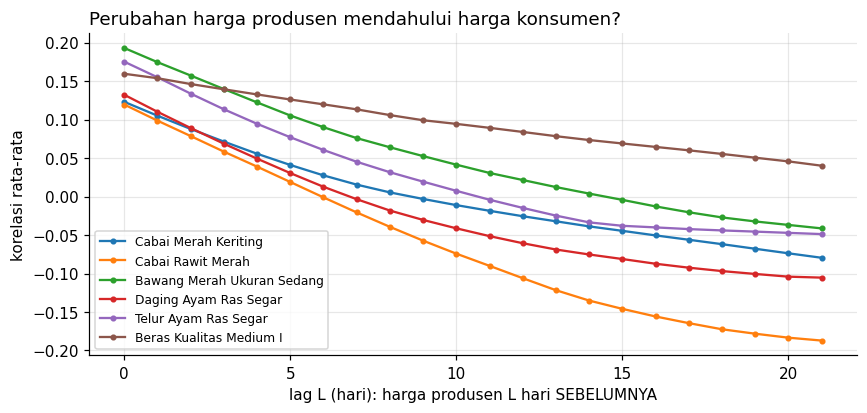

,L=0 hari,L=3 hari,L=7 hari,L=14 hari
Cabai Merah Keriting,0.1230,0.0710,0.0150,-0.0390
Cabai Rawit Merah,0.1200,0.0580,-0.0210,-0.1350
Bawang Merah Ukuran Sedang,0.1930,0.1400,0.0760,0.0040
Daging Ayam Ras Segar,0.1320,0.0690,-0.0030,-0.0750
Telur Ayam Ras Segar,0.1750,0.1130,0.0450,-0.0340
Beras Kualitas Medium I,0.1600,0.1390,0.1130,0.0730


In [17]:
if 4 in set(long["price_type_id"]):
    pan_all, _ = build_price_panels(long[long["price_type_id"].isin([1, 3, 4])], cfg)
    res = {}
    for com_id in ["com_14", "com_16", "com_11", "com_7", "com_10", "com_3"]:
        cons = pan_all[1][com_id]; prod = pan_all[4][com_id] if com_id in pan_all[4].columns.get_level_values(0) else None
        if prod is None: continue
        provs = [p for p in cons.columns if p in prod.columns and p != 0]
        dc = np.log(cons[provs]).diff(14); dp = np.log(prod[provs]).diff(14)
        cors = []
        for L in range(0, 22):
            c = dc.corrwith(dp.shift(L)).mean()
            cors.append(c)
        res[refs["com_name"][com_id]] = cors
    cc = pd.DataFrame(res, index=range(0, 22))
    fig, ax = plt.subplots(figsize=(9, 3.8))
    for col in cc.columns:
        ax.plot(cc.index, cc[col], marker="o", ms=3, label=col)
    ax.set_xlabel("lag L (hari): harga produsen L hari SEBELUMNYA"); ax.set_ylabel("korelasi rata-rata")
    ax.set_title("Perubahan harga produsen mendahului harga konsumen?", loc="left"); ax.legend(fontsize=8)
    fig.savefig(P.figures / "fig_03_09_lead_produsen.png", dpi=160, bbox_inches="tight"); plt.show()
    display(cc.round(3).T[[0, 3, 7, 14]].rename(columns=lambda L: f"L={L} hari"))

,momentum konsumen 14h,perubahan produsen 14h,produsen naik > konsumen,margin konsumen-produsen (z90)
komoditas,,,,
Cabai Merah Keriting,-0.056,-0.039,-0.015,+0.037
Cabai Rawit Merah,+0.135,-0.135,-0.203,+0.115
Bawang Merah Ukuran Sedang,+0.259,+0.004,-0.143,+0.192
Daging Ayam Ras Segar,-0.085,-0.075,-0.005,+0.019
Telur Ayam Ras Segar,+0.080,-0.034,-0.068,+0.073
Beras Kualitas Medium I,+0.193,+0.073,+0.014,+0.009


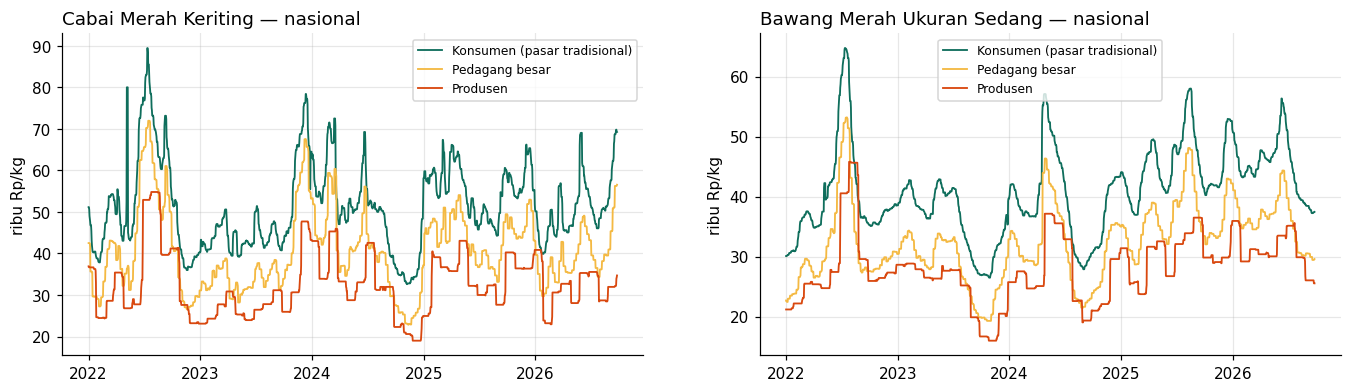

In [18]:
# Uji 2 — daya prediksi: korelasi sinyal HARI INI dengan kenaikan harga konsumen 14 hari KE DEPAN
if 4 in set(long["price_type_id"]):
    rows = []
    for com_id in ["com_14", "com_16", "com_11", "com_7", "com_10", "com_3"]:
        c = np.log(pan_all[1][com_id]); p = np.log(pan_all[4][com_id])
        provs = [x for x in c.columns if x != 0 and x in p.columns]
        fut = (c.shift(-14) - c)[provs]; pc = (c - c.shift(14))[provs]; pp = (p - p.shift(14))[provs]
        mg = (c - p)[provs]; mz = (mg - mg.rolling(90, min_periods=30).mean()) / mg.rolling(90, min_periods=30).std()
        rows.append({"komoditas": refs["com_name"][com_id],
                     "momentum konsumen 14h": fut.corrwith(pc).mean(),
                     "perubahan produsen 14h": fut.corrwith(pp).mean(),
                     "produsen naik > konsumen": fut.corrwith(pp - pc).mean(),
                     "margin konsumen-produsen (z90)": fut.corrwith(mz).mean()})
    pred_corr = pd.DataFrame(rows).set_index("komoditas")
    display(pred_corr.style.format("{:+.3f}").background_gradient(cmap="RdBu_r", vmin=-.3, vmax=.3))
    pred_corr.to_csv(P.tables / "03_korelasi_prediktif_rantai_pasok.csv")

# Harga nasional konsumen vs pedagang besar vs produsen: contoh cabai merah keriting & bawang merah
if 4 in set(long["price_type_id"]):
    fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
    for ax, com_id in zip(axes, ["com_14", "com_11"]):
        for pt, lbl, col in [(1, "Konsumen (pasar tradisional)", PALETTE["accent"]), (3, "Pedagang besar", PALETTE["watch"]), (4, "Produsen", PALETTE["high"])]:
            if pt in pan_all and (com_id, 0) in pan_all[pt].columns:
                s = pan_all[pt][(com_id, 0)].loc["2022":]
                ax.plot(s.index, s / 1000, label=lbl, lw=1.2, color=col)
        ax.set_title(f"{refs['com_name'][com_id]} — nasional", loc="left"); ax.set_ylabel("ribu Rp/kg"); ax.legend(fontsize=8)
    fig.savefig(P.figures / "fig_03_10_rantai_pasok.png", dpi=160, bbox_inches="tight"); plt.show()

**Temuan (jujur):** pada level provinsi, perubahan harga produsen **tidak terlihat mendahului** harga konsumen secara linear — korelasi silang tertinggi justru di lag 0 dan nilainya kecil, dan perubahan produsen 14 hari hampir tidak berkorelasi (bahkan cenderung negatif) dengan kenaikan konsumen ke depan. Yang lebih kuat adalah **momentum harga konsumen sendiri** (terutama bawang merah & beras) dan **margin konsumen–produsen yang melebar di atas normal** (bawang merah, cabai rawit).
Artinya hipotesis "selisih produsen–konsumen sebagai sinyal awal" **belum terbukti secara linear**; kontribusinya diuji ulang di model non-linear lewat **ablation & SHAP** (notebook 06).

### (f) Keterkaitan antarprovinsi: makin dekat, makin mirip pergerakannya?

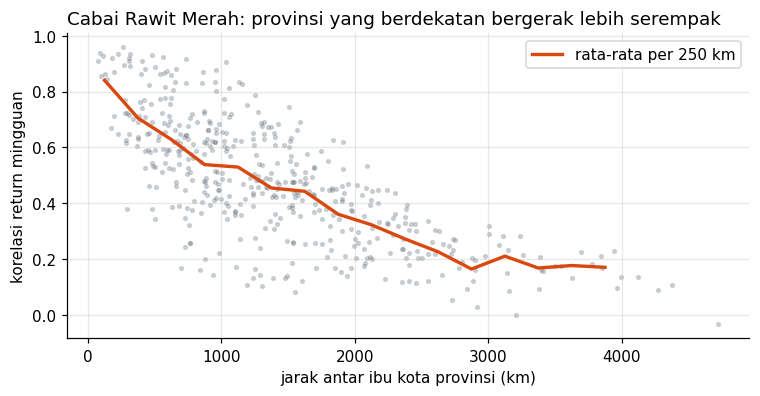

Korelasi rata-rata: <500 km = 0.74 | >2000 km = 0.24


In [19]:
from radarpangan.reference import distance_matrix
D = distance_matrix()
wr = np.log(Pc["com_16"]).resample("W-FRI").mean().diff().drop(columns=[0], errors="ignore")
C = wr.corr(min_periods=100)
pairs = [(D.at[a, b], C.at[a, b]) for i, a in enumerate(C.index) for b in C.index[i + 1:] if np.isfinite(C.at[a, b])]
dd, cc2 = np.array(pairs).T
bins = np.arange(0, 4001, 250); mid = (bins[:-1] + bins[1:]) / 2
bm = [np.nanmean(cc2[(dd >= lo) & (dd < hi)]) if ((dd >= lo) & (dd < hi)).any() else np.nan for lo, hi in zip(bins[:-1], bins[1:])]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.scatter(dd, cc2, s=6, alpha=.25, color=PALETTE["muted"])
ax.plot(mid, bm, color=PALETTE["high"], lw=2.2, label="rata-rata per 250 km")
ax.set_xlabel("jarak antar ibu kota provinsi (km)"); ax.set_ylabel("korelasi return mingguan")
ax.set_title("Cabai Rawit Merah: provinsi yang berdekatan bergerak lebih serempak", loc="left"); ax.legend()
fig.savefig(P.figures / "fig_03_11_jarak_vs_korelasi.png", dpi=160, bbox_inches="tight"); plt.show()
print(f"Korelasi rata-rata: <500 km = {np.nanmean(cc2[dd < 500]):.2f} | >2000 km = {np.nanmean(cc2[dd > 2000]):.2f}")

### (g) Curah hujan & harga cabai
Korelasi anomali hujan 30 hari di sentra produksi (Jawa, NTB, Sulsel, Sumut) pada `t−L` dengan kenaikan harga nasional 14 hari ke depan.

lag hujan (hari),0,10,20,30,40,50,60,70,80,90,100,110,120
Cabai Merah Keriting,0.0160,-0.0500,-0.0710,-0.1150,-0.1040,-0.0900,-0.0120,0.0780,0.1230,0.1380,0.0820,0.0000,-0.0630
Cabai Rawit Merah,0.1170,0.0070,-0.1510,-0.2940,-0.2550,-0.1070,0.0970,0.1960,0.1870,0.1080,0.0050,-0.0610,-0.0670
Bawang Merah Ukuran Sedang,0.0520,0.0560,0.0100,-0.0700,-0.1050,-0.0950,-0.0800,-0.0790,-0.0750,-0.0540,-0.0250,-0.0140,-0.0490


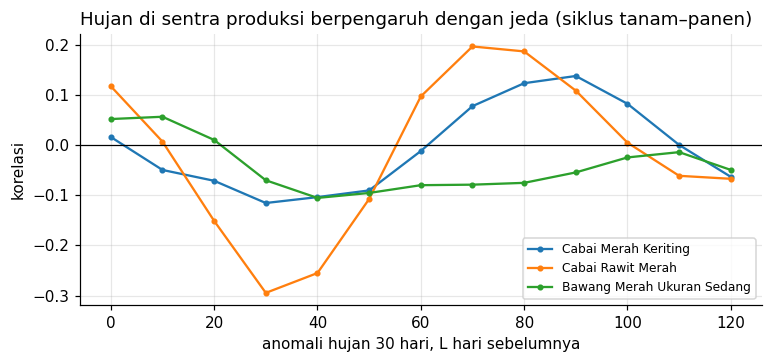

In [20]:
from radarpangan.weather import rainfall_anomalies
rain = pd.read_parquet(P.interim / "rainfall_daily.parquet")
anom = rainfall_anomalies(rain, cfg["weather"]["climatology_start"], cfg["weather"]["climatology_end"], windows=(30,))
name_to_id = {v: k for k, v in refs["prov_name"].items()}
sentra = [name_to_id[n] for n in cfg["features"]["sentra_provinces"]]
ra = anom["rain_30_anom"][sentra].mean(axis=1)
fut = {}
for com_id in ["com_14", "com_16", "com_11"]:
    s = np.log(natP[com_id]); f14 = s.shift(-14) - s
    fut[refs["com_name"][com_id]] = [f14.corr(ra.shift(L).reindex(f14.index)) for L in range(0, 121, 10)]
rc = pd.DataFrame(fut, index=range(0, 121, 10)); rc.index.name = "lag hujan (hari)"
display(rc.round(3).T)
fig, ax = plt.subplots(figsize=(8, 3.2))
for col in rc.columns:
    ax.plot(rc.index, rc[col], marker="o", ms=3, label=col)
ax.axhline(0, color="k", lw=.8); ax.set_xlabel("anomali hujan 30 hari, L hari sebelumnya"); ax.set_ylabel("korelasi")
ax.set_title("Hujan di sentra produksi berpengaruh dengan jeda (siklus tanam–panen)", loc="left"); ax.legend(fontsize=8)
fig.savefig(P.figures / "fig_03_12_hujan_lag.png", dpi=160, bbox_inches="tight"); plt.show()

**Temuan:** hubungan hujan–harga cabai **tertunda**: anomali hujan sekitar 1 bulan sebelumnya berkorelasi negatif, sedangkan sekitar 2–3 bulan sebelumnya berkorelasi positif dengan kenaikan harga cabai rawit (konsisten dengan siklus tanam–panen: hujan ekstrem merusak tanaman → pasokan turun beberapa minggu kemudian). → Fitur hujan dibuat dengan jendela 7/30/90 hari **dan versi ber-lag 60 hari**.

## 3.4 Kesimpulan Data Understanding

| Temuan | Implikasi untuk Data Preparation / Modeling |
|---|---|
| Data harga lengkap sejak 2018, hanya hari kerja, ada baris dummy & salah input | Pembersihan + panel kalender harian + ffill terbatas |
| Volatilitas sangat berbeda antar komoditas | **Ambang lonjakan per kategori** (beras 5%, gula/minyak/sapi 7,5%, lainnya 15%) |
| Lonjakan musiman menjelang Idulfitri & akhir tahun | Fitur kalender (jarak ke Ramadan, Idulfitri, Iduladha, Natal, Tahun Baru) |
| Provinsi berdekatan bergerak serempak | Fitur **tetangga geografis** |
| Harga produsen tidak mendahului secara linear; momentum konsumen & margin di atas normal lebih informatif | Fitur momentum + **margin rantai pasok** tetap dibuat, kontribusinya dibuktikan lewat ablation & SHAP |
| Pengaruh hujan tertunda 1–3 bulan | Fitur anomali hujan 7/30/90 hari + lag 60 hari (provinsi & sentra produksi) |
| Pola spasial berbeda per komoditas | Fitur **provinsi pemimpin** dari jaringan lead-lag (dipelajari dari data latih saja) |

➡️ Lanjut ke **`04_data_preparation.ipynb`**.